Mounted at /content/drive


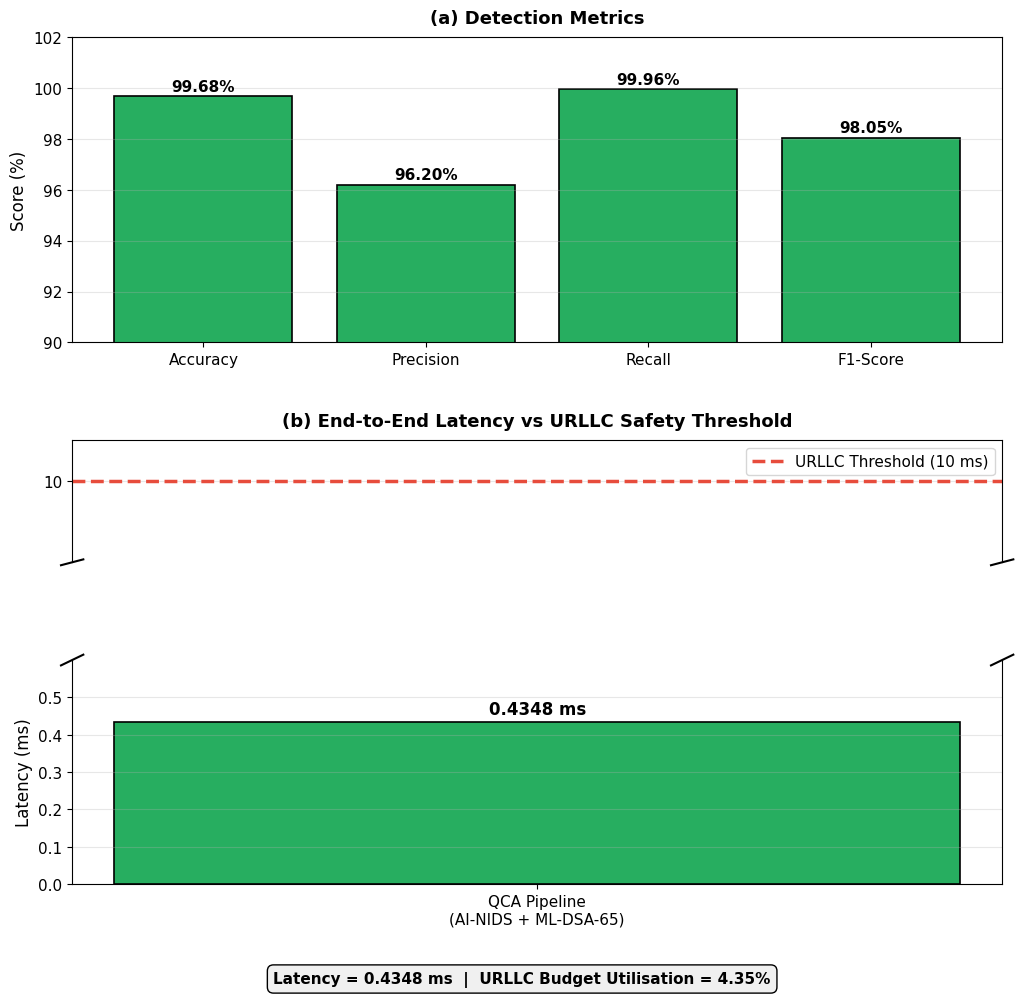

Saved: /content/drive/MyDrive/veremi_thesis/figure_qca_github.png


In [ ]:
# ============================================================
# Figure 12: QCA-Integrated Pipeline Performance Metrics
# GitHub version (with (a) and (b) panel titles)
# ============================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# ============================================================
# CONFIGURATION
# ============================================================
QCA_COLOR = "#27ae60"
THRESHOLD_COLOR = "#e74c3c"

# Locked empirical values (from Google Colab evaluation)
qca_metrics = [99.68, 96.20, 99.96, 98.05]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
qca_latency = 0.4348       # ms (QCA pipeline total latency)
urllc_threshold = 10.0     # ms (V2X URLLC safety threshold)

# ============================================================
# CREATE FIGURE
# ============================================================
fig = plt.figure(figsize=(12, 11))
gs = GridSpec(3, 1, figure=fig, height_ratios=[3, 1.2, 2.2], hspace=0.45)

# Top panel: Detection Metrics
ax1 = fig.add_subplot(gs[0])
bars1 = ax1.bar(metric_labels, qca_metrics, color=QCA_COLOR,
                edgecolor="black", linewidth=1.2)
ax1.set_ylabel("Score (%)", fontsize=12)
ax1.set_title("(a) Detection Metrics", fontsize=13, fontweight="bold", pad=10)
ax1.set_ylim(90, 102)
ax1.grid(axis="y", alpha=0.3)
ax1.tick_params(axis='both', labelsize=11)
for bar, val in zip(bars1, qca_metrics):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.2,
             f"{val:.2f}%", ha="center", fontsize=11, fontweight="bold")

# Middle panel: URLLC zone (8-11 ms)
ax2_upper = fig.add_subplot(gs[1])
ax2_upper.bar(["QCA Pipeline\n(AI-NIDS + ML-DSA-65)"], [qca_latency],
              color=QCA_COLOR, edgecolor="black", linewidth=1.2, width=0.4)
ax2_upper.axhline(y=urllc_threshold, color=THRESHOLD_COLOR, linestyle="--",
                  linewidth=2.5, label="URLLC Threshold (10 ms)")
ax2_upper.set_ylim(8, 11)
ax2_upper.spines['bottom'].set_visible(False)
ax2_upper.tick_params(labelbottom=False, bottom=False)
ax2_upper.set_title("(b) End-to-End Latency vs URLLC Safety Threshold",
                    fontsize=13, fontweight="bold", pad=10)
ax2_upper.legend(loc="upper right", fontsize=11)
ax2_upper.grid(axis="y", alpha=0.3)
ax2_upper.tick_params(axis='y', labelsize=11)
ax2_upper.set_yticks([10])
ax2_upper.set_yticklabels(["10"])

# Bottom panel: Zoomed latency (0-0.6 ms)
ax2_lower = fig.add_subplot(gs[2])
bars2 = ax2_lower.bar(["QCA Pipeline\n(AI-NIDS + ML-DSA-65)"], [qca_latency],
                      color=QCA_COLOR, edgecolor="black", linewidth=1.2,
                      width=0.4)
ax2_lower.set_ylabel("Latency (ms)", fontsize=12)
ax2_lower.set_ylim(0, 0.6)
ax2_lower.spines['top'].set_visible(False)
ax2_lower.grid(axis="y", alpha=0.3)
ax2_lower.tick_params(axis='both', labelsize=11)
ax2_lower.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax2_lower.set_yticklabels(["0.0", "0.1", "0.2", "0.3", "0.4", "0.5"])

# Bar value label
for bar, val in zip(bars2, [qca_latency]):
    ax2_lower.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                   f"{val} ms", ha="center", fontsize=12, fontweight="bold")

# Break marks
d = 0.012
kwargs = dict(transform=ax2_upper.transAxes, color='k', clip_on=False, linewidth=1.5)
ax2_upper.plot((-d, +d), (-d * 2, +d * 2), **kwargs)
ax2_upper.plot((1 - d, 1 + d), (-d * 2, +d * 2), **kwargs)
kwargs.update(transform=ax2_lower.transAxes)
ax2_lower.plot((-d, +d), (1 - d * 2, 1 + d * 2), **kwargs)
ax2_lower.plot((1 - d, 1 + d), (1 - d * 2, 1 + d * 2), **kwargs)

# Summary annotation
budget_pct = (qca_latency / urllc_threshold) * 100
fig.text(0.5, 0.02,
         f"Latency = {qca_latency} ms  |  URLLC Budget Utilisation = {budget_pct:.2f}%",
         ha="center", fontsize=11, fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="black"))

# ============================================================
# SAVE AND DISPLAY
# ============================================================
output_path = "/content/drive/MyDrive/veremi_thesis/figure_qca_github.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")